##### Instructions
- Keep the original structure, you may add additional code cells and/or mark-down cells for clarity, legibility and/or structure.
- Add the required descriptions, explanations, justifications to the mark-down cells.

# EXAM03: Data Science Group Assignment - Iteration 3

**Group name:** Need Help

**Student names & numbers:**
* [Xue Hu] - [100193]
* [Roos Hogervorst] - [101484]
* [Sas van Damme] - [101990]

---

## 0. Iteration setup

**Import libraries**

In [150]:
# CODE CELL: Import the necessary libraries for this iteration (including scikit-learn models and metrics)
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

**Load & Merge dataset(s)**

In [151]:
# CODE CELL: Import the necessary datasets for this iteration.
# Load your fully cleaned dataset from Iteration 2 AND the new performance logs.
# Merge them together based on the Ship_ID
df_performance = pd.read_csv("./data/ship_performance_logs_iter3.csv")
df_inventory_inspections = pd.read_csv("./data/ships_merged.csv")

df = df_inventory_inspections.merge(df_performance, on="Ship_ID", how="left")

---

## 1. Business Understanding

**Situation description**

*Describe the final problem. Why is Nebula Brokerage moving from the simple models (iterations 1 and 2) to a machine learning approach?*

**Business objective(s)**

*Justify why an AI-driven pipeline (predicting both Galactic Credits and Condition) adds business value.*

**Data mining goal(s)**

*Explain the two modeling tasks for this iteration.*

**Success criteria**

*Determine the success criteria.*

---

## 2. Data Understanding

**Data exploration (New Features)**

*Show the summary statistics for the newly merged data. Focus your description on the new variables: Lightyears_Traveled and Registration_Status.*

In [152]:
# CODE CELL: Show basic statistics and information for the final merged dataset
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 355071 entries, 0 to 355070
Data columns (total 12 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Ship_ID                   355071 non-null  int64  
 1   Galactic_Credits          355071 non-null  int64  
 2   Model_Cycle               355071 non-null  float64
 3   Ship_Manufacturer         355071 non-null  str    
 4   Sector                    355071 non-null  str    
 5   Hull_Integrity            355071 non-null  str    
 6   Reactor_Power             355071 non-null  float64
 7   Propulsion_Type           355071 non-null  str    
 8   Ship_Class                355071 non-null  str    
 9   Predicted_Hull_Integrity  355071 non-null  str    
 10  Lightyears_Traveled       351651 non-null  float64
 11  Registration_Status       351651 non-null  str    
dtypes: float64(3), int64(2), str(7)
memory usage: 32.5 MB


,Ship_ID,Galactic_Credits,Model_Cycle,Reactor_Power,Lightyears_Traveled
count,3.550710e+05,355071.000000,355071.000000,355071.000000,351651.000000
mean,7.311481e+09,18676.428799,7511.248353,68.929651,105.027135
std,4.382615e+06,13250.473090,8.956381,38.278429,88.960987
min,7.301583e+09,501.000000,7400.000000,30.000000,0.000000
25%,7.308096e+09,7900.000000,7508.000000,40.000000,30.743526
50%,7.312595e+09,15800.000000,7513.000000,60.000000,85.750730
75%,7.315242e+09,27500.000000,7517.000000,80.000000,157.834571
max,7.317101e+09,68788.000000,7522.000000,240.000000,1559.606111


**Visualizations and patterns**
*Create visualizations to discover the impact of the new features.

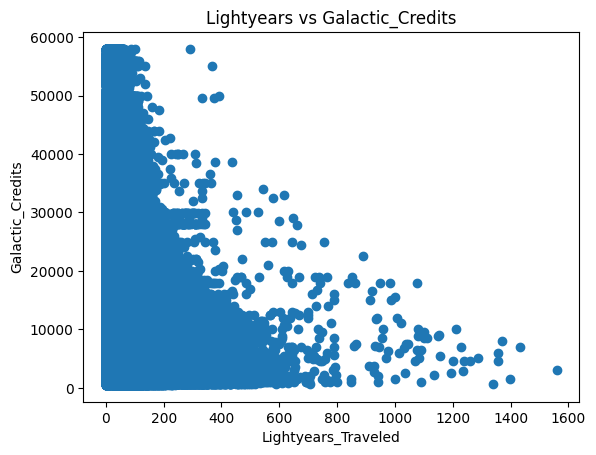

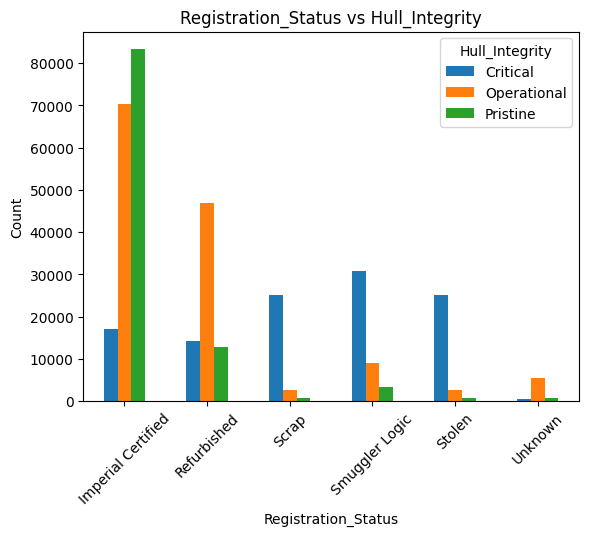

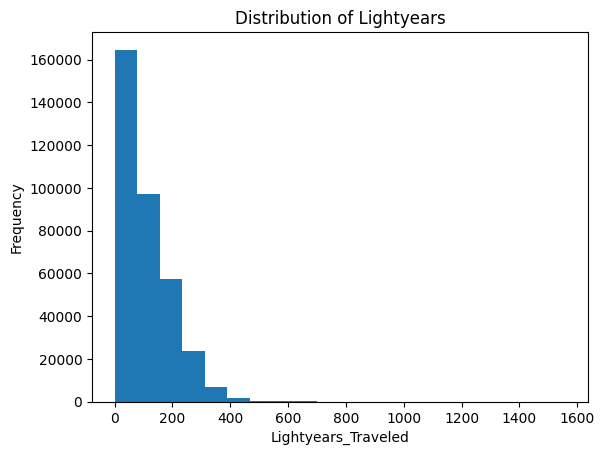

In [153]:
# CODE CELL: Generate visualizations for the new features

# Scatter plot of Lightyears_Traveled vs Galactic_Credits
plt.scatter(df["Lightyears_Traveled"], df["Galactic_Credits"])
plt.xlabel("Lightyears_Traveled")
plt.ylabel("Galactic_Credits")
plt.title("Lightyears vs Galactic_Credits")
plt.show()

# Bar plot of Engine_Efficiency by Registration_Status
pd.crosstab(df["Registration_Status"], df["Hull_Integrity"]).plot(kind="bar")
plt.xlabel("Registration_Status")
plt.xticks(rotation=45)
plt.ylabel("Count")
plt.title("Registration_Status vs Hull_Integrity")
plt.show()

# Histogram of Lightyears_Traveled
plt.hist(df["Lightyears_Traveled"], bins=20)
plt.xlabel("Lightyears_Traveled")
plt.ylabel("Frequency")
plt.title("Distribution of Lightyears")
plt.show()


**Data insights and data quality**

* **Insights:** Does high mileage lower the price? Does a 'Stolen' status correlate with critical hull condition?
* **Quality issues:** Document any missing values and other issues

**Insights:**
1. Higher mileage leads to lower prices, indicating that usage is a key factor in price determination.
2. ships with “Stolen”, “Smuggler Logic” or "Scrap" status have a much higher proportion of Critical conditions, while “Imperial Certified” ships are mostly in better condition.

**Quality issues:**
1. Lightyears_Traveled and Registration_Status contain missing values and should be checked and handled.
2. Most ships have low mileage, while a few have extremely high mileage, indicating a right-skewed distribution with potential outliers.

---

## 3. Data Preparation

**Cleaning and preprocessing**

*Describe and justify how you resolve your data errors.*

In [154]:
# CODE CELL: Data cleaning, preprocessing
df.duplicated().sum()

# check possible typos in categorical columns
print(df["Registration_Status"].unique())

# fill missing values in Lightyears_Traveled with median
df["Lightyears_Traveled"] = df["Lightyears_Traveled"].fillna(df["Lightyears_Traveled"].median())

missing_data = df[df['Registration_Status'].isnull()]
print(missing_data['Hull_Integrity'].value_counts())

# fill missing values in Registration_Status with "Missing"
df["Registration_Status"] = df["Registration_Status"].fillna("Missing")

# check for outliers in Lightyears_Traveled using IQR method
Q1 = df["Lightyears_Traveled"].quantile(0.25)
Q3 = df["Lightyears_Traveled"].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR
outliers = df[df["Lightyears_Traveled"] > upper_bound]
print("Outliers in Hull_Integrity:", outliers["Hull_Integrity"].value_counts())

df.info()
df.describe()

<StringArray>
[    'Smuggler Logic', 'Imperial Certified',            'Unknown',
                  nan,        'Refurbished',             'Stolen',
              'Scrap']
Length: 7, dtype: str
Hull_Integrity
Pristine       2290
Operational     853
Critical        277
Name: count, dtype: int64
Outliers in Hull_Integrity: Hull_Integrity
Critical       4416
Operational     344
Pristine         55
Name: count, dtype: int64
<class 'pandas.DataFrame'>
RangeIndex: 355071 entries, 0 to 355070
Data columns (total 12 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Ship_ID                   355071 non-null  int64  
 1   Galactic_Credits          355071 non-null  int64  
 2   Model_Cycle               355071 non-null  float64
 3   Ship_Manufacturer         355071 non-null  str    
 4   Sector                    355071 non-null  str    
 5   Hull_Integrity            355071 non-null  str    
 6   Reactor_Power           

,Ship_ID,Galactic_Credits,Model_Cycle,Reactor_Power,Lightyears_Traveled
count,3.550710e+05,355071.000000,355071.000000,355071.000000,355071.000000
mean,7.311481e+09,18676.428799,7511.248353,68.929651,104.841467
std,4.382615e+06,13250.473090,8.956381,38.278429,88.551535
min,7.301583e+09,501.000000,7400.000000,30.000000,0.000000
25%,7.308096e+09,7900.000000,7508.000000,40.000000,31.119467
50%,7.312595e+09,15800.000000,7513.000000,60.000000,85.750730
75%,7.315242e+09,27500.000000,7517.000000,80.000000,156.981369
max,7.317101e+09,68788.000000,7522.000000,240.000000,1559.606111


**Explanation:**
1. Missing values in Lightyears_Traveled were filled using the median. This variable is right-skewed and contains extreme values, so the median provides a more robust estimate than the mean.

2. Missing values in Registration_Status were labeled as "Missing" because they are not randomly distributed (mostly associated with Pristine ships, possibly newly produced and not yet registered); assigning them to an existing category such as "Unknown", which already shows a different pattern (mainly Operational), would mix distinct meanings and distort relationships, while imputing values based on Hull_Integrity would mean using the answer (the target) to guess the input, which would create artificial patterns and make the model unreliable.

3. Outliers in Lightyears_Traveled were identified using the IQR method. Most of these observations are associated with Critical hull conditions, suggesting that they likely represent Pristine ships rather than data errors. Therefore, they were retained as valid extreme cases.

**Feature encoding**

*Describe how you converted your categorical columns into a format the model can use.*

In [155]:
# CODE CELL: Apply feature ecoding and define your features (X)
y_reg = df["Galactic_Credits"]
y_clf = df["Hull_Integrity"]

X = df.drop(["Galactic_Credits", "Hull_Integrity"], axis=1)

X_encoded = pd.get_dummies(X, drop_first=True)

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_encoded, y_reg, test_size=0.2, random_state=42
)

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_encoded, y_clf, test_size=0.2, random_state=42
)

**Explanation:**

To prepare the data for modeling, all categorical columns were converted into numerical format using one-hot encoding. This ensures that the machine learning models can interpret categorical features correctly.

Using drop_first=True to avoid multicollinearity by removing the first category of each feature.

The dataset was split into training and testing sets for both regression (Galactic_Credits) and classification (Hull_Integrity) tasks using an 80/20 split.

---

## 4. Modeling: Task A

**Regression setup**

*Set up a [Linear Regression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html) model to predict `Galactic_Credits`. Make sure to split your data into training and testing sets.*

In [156]:
# CODE CELL: Train-Test split & train the Linear Regression model

**Testing and performance (Regression)**

*Calculate the MAE, RMSE and R2 score. Create a plot showing Actual vs. Predicted prices to visually verify model performance.*

In [157]:
# CODE CELL: Evaluate the rgression model and plot Actual vs Predicted

---

## 5. Modeling: Task B

**Classification setup**

*Set up a [Decision Tree Classifier](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html) to predict `Hull_Integrity`. Split the data into training and testing sets.*

In [158]:
# CODE CELL: Train-Test split & train the Decision Tree model.

**Testing and performance (classification)**

*Calculate the Accuracy and plot a confusion matrix. Explain what the matrix tells you about the predictions.*

In [159]:
# CODE CELL: Evaluate your classification model (check ou tthe metrics, include a confusion matrix)

---

## 6. Evaluation

**Assessment against success criteria** 

*Compare your models to the baselines:*
* *Are thr scores of this regression model better than Iteration 1? Why?*
* *Are the scores of the decision tree better than your manual rules from Iteration 2? Why?*

**Key findings and limitations**

*What are the final conclusions? Should Nebula Brokerage deploy these models? What are the remaining limitations?*

Use [pandas' to_csv](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.to_csv.html) to export your cleaned and merged dataset.

---

## 7. Personal Contribution

| Student name | Contribution | Personal lessons learned |
| :--- | :--- | :--- |
| Xue | *Analyzed new features using visualizations to identify relationships , handled data quality issues and prepared the data through one-hot encoding and train-test splitting.* | *Non-random missing data must be handled carefully to avoid bias, and multicollinearity can occur when encoding categorical variables, which should be addressed (e.g. using drop_first) to improve model stability.* |
| Student name 2 | *Contribution description* | *Personal lessons learned this iteration* |
| Student name 3 | *Contribution description* | *Personal lessons learned this iteration* |